<!-- criterio de correcao: criar em qualquer celula de resposta uma variavel, funcao, parametro ou chave de dicionario com o nome exato _check -->
# Exercício 13 — Projeto 3: case de aprendizado de máquina (peso 2)

Este é o **Projeto 3**, a entrega que fecha o bloco de aprendizado de máquina. Ele **vale o dobro** de um projeto normal, e junta as três aulas do bloco numa análise só, feita na **sua coleta de rede social** (a mesma das Aulas 5 a 7 e dos Exercícios 11 e 12).

Você vai entregar três peças sobre a mesma coleta:

- **Parte A — Regressão (Aula 11):** criar e justificar uma variável contínua como alvo, treinar linear + árvore, comparar com o modelo bobo.
- **Parte B — Classificação (Aula 12):** criar e justificar o rótulo "viralizou" por um corte, treinar um classificador, ler a matriz de confusão.
- **Parte C — Segmentação (Aula 13):** agrupar posts, autores ou hashtags da sua coleta e descrever cada segmento com números.

Não é para inventar coleta nova. Copie a sua `exportacao.csv` para `dados/exportacao. csv` nesta pasta. Ou então realize uma nova... Antes de tudo, copie a pasta `exercicios/` para dentro da sua pasta de entregas (`extracao-dados-trabalhos-seunome`), numa pasta `13-segmentacao-clusterizacao` dentro de `projetos/`.

**Como este projeto vale ponto e o dobro do peso, ele passa por defesa curta:** você pode ser chamado para explicar uma decisão, reproduzir uma etapa ou fazer uma pequena alteração ao vivo.

## Preparação do ambiente

Dentro da pasta, no Windows (Prompt de Comando ou Terminal integrado do VS Code):

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

No Mac (Terminal), os mesmos comandos. Se o `uv` não funcionar, `pip install -r requirements.txt` com o ambiente ativado.

## Parte 0 — Dados e decisões

**Fonte e período da coleta:**

> Fonte: Exportação do TikTok via Zeeschuimer, Aula 7. Período: 19/08/2026

**Variável contínua que você vai prever na Parte A (e por quê):**

> A variável contínua que será prevista é a taxa de engajamento de um post a partir das características do autor, do texto e do horário do post. Essa escolha foi feita, pois conseguir prever uma taxa de engajamento a partir de características diversas pode ajudar autores a saberem no que precisam investir para que seus posts possuam maior engajamento médio.

**Como você vai definir "viralizou" na Parte B (o corte e a justificativa):**

> Vou marcar como 'viralizou' os posts com plays acima do percentil 75 da minha coleta. Desse modo, cerca de 25% dos posts será classificao como viral. Por exemplo, se fosse colocado como viral posts com plays acima do percentil 90, a quantidade de posts marcadas como viral seria extremamente baixa, ainda mais porque a coleta de posts não é tão grande. Usar o percentil 75 seria mais "justo" em uma coleta pequena como está (1138 posts), visto que o objetivo é ver posts que performaram relativamente melhor do que a maioria (nada muito exagerado), e não selecionar apenas os posts que tiveram uma performance de extrema viralização. 

**O que você vai segmentar na Parte C (posts, autores ou hashtags) e com quais características:**

> Irei segmentar posts a partir das seguintes características: likes, shares, comments e plays.

## Parte 1 — Carregar a coleta e montar as features

Ajuste os nomes de coluna se a sua plataforma for diferente. **Regra de ouro:** as colunas de interação (`likes`, `comments`, `shares`, `plays`) não entram como feature nas Partes A e B, porque são o alvo (vazamento).

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [225]:
df = pd.read_csv("dados/exportacao.csv", sep=";")
df = df.drop_duplicates()
df = df[df["plays"] > 0].copy()

# --- features derivadas, todas "de antes da publicação" ---
X = pd.DataFrame(index=df.index)  # tabela de features vazia, mesmo índice de df

# do autor
X["seguidores_autor"] = df["author_followers"]  # tamanho da audiência de quem postou
X["videos_autor"] = df["author_videos"]  # quantos vídeos o autor já publicou no total

# do texto (coluna body = legenda do post)
X["tam_legenda"] = df["body"].fillna("").str.len()  # nº de caracteres da legenda
padrao_emoji = re.compile("[\U0001F000-\U0001FAFF\u2600-\u27BF]")  # faixa Unicode de emojis
X["n_emojis"] = df["body"].fillna("").apply(lambda s: len(padrao_emoji.findall(s)))

# das hashtags (string separada por vírgula, pode ser vazia)
X["n_hashtags"] = df["hashtags"].fillna("").apply(
    lambda s: 0 if s == "" else len(s.split(","))
)

# do horário
momento = pd.to_datetime(df["timestamp"])  # converte o texto de data para datetime
X["hora"] = momento.dt.hour  # 0 a 23
X["dia_semana"] = momento.dt.dayofweek  # 0 = segunda ... 6 = domingo

X.head() 

print("Features criadas:", list(X.columns))
X.head()

Features criadas: ['seguidores_autor', 'videos_autor', 'tam_legenda', 'n_emojis', 'n_hashtags', 'hora', 'dia_semana']


,seguidores_autor,videos_autor,tam_legenda,n_emojis,n_hashtags,hora,dia_semana
0,2648,255,28,1,0,19,3
1,1300000,3430,25,0,4,16,2
2,185300,2464,15,0,1,21,2
3,1708,32,44,0,1,11,0
4,12900,146,71,0,3,15,0


## Parte A — Regressão

Complete: construa a variável contínua que você definiu na Parte 0 (`y_reg`), separe treino/teste, treine `LinearRegression` e `DecisionTreeRegressor(max_depth=5, random_state=42)`, e compare os dois com o modelo bobo (prever a média) usando MAE e R².

In [226]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# complete aqui: y_reg, split, modelo bobo, linear, árvore, e o print comparando os três

In [227]:
# y_reg

df["taxa_engajamento"] = (
    df["likes"] + df["comments"] + df["shares"]
) / df["plays"]

y_reg = df["taxa_engajamento"]
print(f"Posts na base: {len(df)}")
print(y_reg.describe())


Posts na base: 1138
count    1138.000000
mean        0.038749
std         0.047725
min         0.000000
25%         0.009511
50%         0.019851
75%         0.048251
max         0.451807
Name: taxa_engajamento, dtype: float64


In [228]:
# split
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y_reg, test_size=0.25, random_state=42
)

# modelo bobo: prever sempre a média do treino
previsao_boba = np.full(len(y_teste), y_treino.mean())
mae_bobo = mean_absolute_error(y_teste, previsao_boba)
r2_bobo = r2_score(y_teste, previsao_boba)

# regressão linear
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)
previsoes = modelo_linear.predict(X_teste)
mae_linear = mean_absolute_error(y_teste, previsoes)
r2_linear = r2_score(y_teste, previsoes)

print(f"Modelo bobo:       MAE = {mae_bobo:.4f}   R2 = {r2_bobo:.3f}")
print(f"Regressão linear:  MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")

Modelo bobo:       MAE = 0.0324   R2 = -0.000
Regressão linear:  MAE = 0.0330   R2 = -0.007


In [229]:
# árvore de decisão

modelo_arvore = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino, y_treino)
previsoes_arvore = modelo_arvore.predict(X_teste)

mae_arvore = mean_absolute_error(y_teste, previsoes_arvore)
r2_arvore = r2_score(y_teste, previsoes_arvore)

print(f"Modelo bobo:        MAE = {mae_bobo:.4f}   R2 = {r2_bobo:.3f}")
print(f"Regressão linear:   MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")
print(f"Árvore (prof. 5):   MAE = {mae_arvore:.4f}   R2 = {r2_arvore:.3f}")

# MAE deve ser o menor possível (quanto mais próximo de 0, menos o modelo está errando). R2 deve ser o maior possível 
#(quanto mais próximo de 1, melhor o modelo está performando - é melhor do que só chutar a média, nesse caso da taxa de engajamento).

Modelo bobo:        MAE = 0.0324   R2 = -0.000
Regressão linear:   MAE = 0.0330   R2 = -0.007
Árvore (prof. 5):   MAE = 0.0323   R2 = -0.295


## Parte B — Classificação

Complete: construa o rótulo `y_clf` (0/1) pelo corte da Parte 0, separe treino/teste com `stratify=y_clf`, treine `LogisticRegression(max_iter=1000)`, imprima a matriz de confusão e precisão/recall/F1, e teste **um** threshold diferente de 0,5.

In [230]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [231]:
corte = df["plays"].quantile(0.75)  # o valor de plays que separa os 25% virais
y_clf = (df["plays"] > corte).astype(int)  # 1 = viralizou, 0 = não

print(f"Corte (percentil 75 de plays): {int(corte):,} visualizações")
print(f"Posts marcados como 'viralizou': {y.sum()} de {len(y)}  ({y.mean():.0%})")

Corte (percentil 75 de plays): 688,375 visualizações
Posts marcados como 'viralizou': 285 de 1138  (25%)


In [232]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

modelo = LogisticRegression(max_iter=2000) # o exercício pede max_inter=1000, porém ela da erro de convergência, então aumentei para 2000.
modelo.fit(X_treino, y_treino)
decisao = modelo.predict(X_teste)
probabilidade = modelo.predict_proba(X_teste)[:, 1]

cm = confusion_matrix(y_teste, decisao)
print("Matriz de confusão:")
print(f"                 modelo: não   modelo: viral")
print(f"  era não:        {cm[0,0]:>6}        {cm[0,1]:>6}")
print(f"  era viral:      {cm[1,0]:>6}        {cm[1,1]:>6}")
print()
print(f"Precisão:  {precision_score(y_teste, decisao, zero_division=0):.2f}   (dos que o modelo chamou de viral, quantos eram)")
print(f"Recall:    {recall_score(y_teste, decisao, zero_division=0):.2f}   (dos virais de verdade, quantos o modelo pegou)")
print(f"F1:        {f1_score(y_teste, decisao, zero_division=0):.2f}   (média equilibrada de precisão e recall)")

# leitura da matriz de confusão:
# verdadeiros positivos = 10, falsos negativos = 61, verdadeiros negativos = 211, falsos positivos = 3

Matriz de confusão:
                 modelo: não   modelo: viral
  era não:           211             3
  era viral:          61            10

Precisão:  0.77   (dos que o modelo chamou de viral, quantos eram)
Recall:    0.14   (dos virais de verdade, quantos o modelo pegou)
F1:        0.24   (média equilibrada de precisão e recall)


In [233]:
for t in [0.30]:
    decisao_t = (probabilidade >= t).astype(int)
    p = precision_score(y_teste, decisao_t, zero_division=0)
    r = recall_score(y_teste, decisao_t, zero_division=0)
    f = f1_score(y_teste, decisao_t, zero_division=0)
    vp = int(((decisao_t == 1) & (y_teste.values == 1)).sum())
    fp = int(((decisao_t == 1) & (y_teste.values == 0)).sum())
    print(f"corte = {t:.2f}:  precisão = {p:.2f}  recall = {r:.2f}  F1 = {f:.2f}  -> (pegou {vp} virais, {fp} alarmes falsos)")

corte = 0.30:  precisão = 0.62  recall = 0.32  F1 = 0.43  -> (pegou 23 virais, 14 alarmes falsos)


In [240]:
# decision tree utilizada para comparar com precisão/recall/F1 do modeo de regressão logística

from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
arvore.fit(X_treino, y_treino)
decisao_arvore = arvore.predict(X_teste)

print("Árvore (profundidade 4, class_weight balanced):")
print(f"  precisão {precision_score(y_teste, decisao_arvore, zero_division=0):.2f}"
      f"  recall {recall_score(y_teste, decisao_arvore, zero_division=0):.2f}"
      f"  F1 {f1_score(y_teste, decisao_arvore, zero_division=0):.2f}")


Árvore (profundidade 4, class_weight balanced):
  precisão 0.48  recall 0.61  F1 0.54


## Parte C — Segmentação

Complete: monte uma tabela `base_seg` com uma linha por unidade que você vai segmentar (post, autor ou hashtag) e colunas numéricas de comportamento. Padronize com `StandardScaler`, use a curva do cotovelo / silhueta para escolher `k`, rode `KMeans`, e monte o perfil de cada cluster com `groupby("cluster").mean()`.

In [235]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# complete aqui: base_seg, padronização, escolha de k, KMeans, perfil dos clusters


In [236]:
# só colunas numéricas, sem o id
# colunas_num = df.select_dtypes("number").columns.tolist() -> não usei diretamente desssa forma, pois estava dando colunas completas com "NaN" ou com métricas que não eram de comportamento, por isso fiz um filtro apenas com as colunas de número que eu queria
colunas_num = ["likes", "comments", "shares", "plays"]
print("Colunas usadas:", colunas_num)

base_seg = df[colunas_num].copy()  # base de segmentação, só com colunas numéricas
X = base_seg
# Claude IA utilizado para gerar o código do X_log
X_log = np.log1p(base_seg[colunas_num]) #o log foi utilizado porque as linhas das colunas selecionados, em sua maioria, possuem valores baixos, fazendo com que os clusters ficassem mal distribuídos, visto que eram poucos os valores que "distoavam" do resto, o que fazia eles serem reconhecidos como outliers.
X_padronizado = StandardScaler().fit_transform(X_log)  # média 0, desvio 1 em cada coluna

# conferindo: cada coluna agora tem média ~0 e desvio ~1
pd.DataFrame(X_padronizado, columns=colunas_num).describe().round(2).loc[["mean", "std"]]

Colunas usadas: ['likes', 'comments', 'shares', 'plays']


,likes,comments,shares,plays
mean,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0


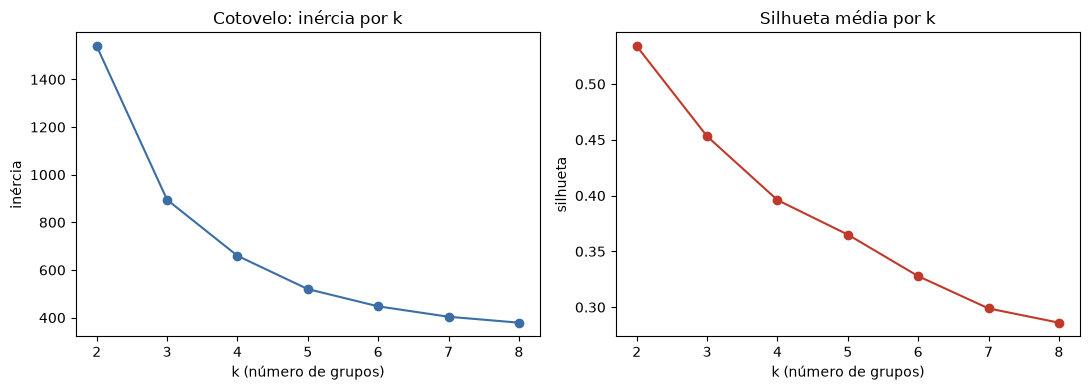

k=2: silhueta 0.534
k=3: silhueta 0.453
k=4: silhueta 0.396
k=5: silhueta 0.365
k=6: silhueta 0.328
k=7: silhueta 0.299
k=8: silhueta 0.286


In [237]:
inercias = []
silhuetas = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_padronizado)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inercias, marker="o", color="#3b6ea5")
ax1.set_title("Cotovelo: inércia por k")
ax1.set_xlabel("k (número de grupos)"); ax1.set_ylabel("inércia")

ax2.plot(list(ks), silhuetas, marker="o", color="#c0392b")
ax2.set_title("Silhueta média por k")
ax2.set_xlabel("k (número de grupos)"); ax2.set_ylabel("silhueta")

fig.tight_layout()
plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta {s:.3f}")

In [238]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
grupos = kmeans.fit_predict(X_padronizado)

base_seg["cluster"] = grupos 

base_seg["cluster"].value_counts().sort_index()

cluster
0    616
1    522
Name: count, dtype: int64

In [239]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
base_seg["cluster"] = kmeans.fit_predict(X_padronizado)

# média de cada coluna, por cluster (nos valores ORIGINAIS, não nos padronizados, para ler melhor)
perfil = base_seg.groupby("cluster")[colunas_num].mean().round(1)
perfil

,likes,comments,shares,plays
cluster,,,,
0,416.3,7.4,38.4,33482.1
1,207348.5,1304.5,9187.3,3574317.2


**Rascunho da descrição dos segmentos (vai para o README):**

> No segmento 0, estão inseridos 616 posts, com uma média de likes de 416.3, média de comentários de 7.4, média de compartilhamentos de 38.4 e média de plays de 33482.1. Já no segmento 1, estão inseridos 522 posts, com uma média de likes de 207348.5, média de comentários de 1304.5, média de compartilhamentos de 9187.3 e média de plays de 3574317.2. Dito isso, é possível observar que o segmento 0 agrupa os posts com métricas menores, enquanto o segmento 1, agrupa posts com métricas maiores

## Parte D — README do case

Crie `README.md` dentro de `projetos/13-segmentacao-clusterizacao/` na sua pasta de entregas:

**Fonte, período e tamanho da coleta:**

> Fonte: Exportação do TikTok via Zeeschuimer, Aula 7. Período: 19/08/2026. Tamanho da coleta: 1138 posts.

**As duas variáveis que você criou (a contínua da Parte A e o rótulo da Parte B), com a fórmula/critério de cada uma:**

> A variável contínua criada na Parte A foi a taxa de engajamento, a partir da fórmula ( df["likes"] + df["comments"] + df["shares"] )/ df["plays"]. O rótulo da Parte B foi o corte no percentil 75 de plays, ou seja, posts com 688,375 plays. Posts que tiveram mais visualizações que isso foram classificados como virais (285 de 1138 da coleta, 25%).

**As features usadas nas Partes A e B, e quais colunas você descartou por vazamento:**

> Features usadas na Parte A e B foram: 'seguidores_autor', 'videos_autor', 'tam_legenda', 'n_emojis', 'n_hashtags', 'hora', 'dia_semana'. Foram descartadas as colunas "likes", "comments", "shares" e "plays", pois eles são diretamente utilizados para fazer o cálculo do engajamento médio (Parte A) e do rótulo de viralização (Parte B), ou seja, utilizar elas seria apenas informar as métricas exatas para calcular as respostas desejadas, isto é, não estaria sendo feita nenhuma previsão.


**Parte A — resultado:** MAE e R² do modelo bobo, da linear e da árvore. O seu melhor modelo bateu o bobo?

> Modelo bobo:  MAE = 0.0324   R2 = -0.000 / Regressão linear:   MAE = 0.0330   R2 = -0.007 / Árvore (prof. 5):   MAE = 0.0323   R2 = -0.295. Neste caso, o melhor MAE alcançado foi o da Árvore, com uma diferença de 0.001 (muito pequena) para o modelo bobo. Já no R2, o melhor continuou sendo o do modelo bobo, visto que o dos algoritmos testados deu um resultado negativo mais alto.

**Parte B — resultado:** a matriz de confusão e uma leitura: a favor de quem o modelo erra?

> A matriz de confusão da regressão logística fica assim: VN = 211 / FN = 61 / FP = 3 / VP = 10. Ele está errando a favor dos falsos negativos, ou seja, existem 61 posts que deveriam ser classificados como virais, mas não estão sendo. Isso também pode ser observado por meio do recall de 0.14, ou seja, ele está baixo, deixando passar muitos posts que deveriam estar sendo considerados como virais.

**Parte C — resultado:** quantos segmentos, como você escolheu `k`, e a descrição de cada segmento (uma frase com número).

> Foram escolhidos 2 segmentos. No segmento 0, estão inseridos 616 posts, com uma média de likes de 416.3, média de comentários de 7.4, média de compartilhamentos de 38.4 e média de plays de 33482.1. Já no segmento 1, estão inseridos 522 posts, com uma média de likes de 207348.5, média de comentários de 1304.5, média de compartilhamentos de 9187.3 e média de plays de 3574317.2. Dito isso, é possível observar que o segmento 0 agrupa os posts com métricas menores, enquanto o segmento 1, agrupa posts com métricas maiores

**Uma conclusão que os seus dados sustentam** (sem extrapolar para além da sua coleta):

> Escreva aqui.

**Revisão por pares:** nome do colega **da turma** que revisou, o que ele apontou, e o que você mudou (ou por que não mudou).

> Escreva aqui.

**Declaração de uso de IA:** ferramenta usada, em que trecho ou decisão, e o que você conferiu ou alterou depois (mesmo que seja "não usei IA nesta entrega"). Lembre: nesta entrega, IA não pode ser usada para gerar o código de análise.

> Escreva aqui.

## Parte E — Conferência final

- [ ] `dados/exportacao.csv` é a sua coleta, e `dados/` está no `.gitignore`.
- [ ] As duas variáveis criadas (contínua e rótulo) estão definidas e justificadas no README.
- [ ] As features das Partes A e B não incluem `likes`/`comments`/`shares`/`plays`.
- [ ] Parte A: linear, árvore e modelo bobo comparados com MAE e R².
- [ ] Parte B: matriz de confusão, precisão/recall/F1 e um threshold alternativo testado.
- [ ] Parte C: escolha de `k` justificada (cotovelo/silhueta) e um perfil por cluster com números.
- [ ] O README responde todas as perguntas da Parte D, incluindo a revisão por pares.
- [ ] Este notebook roda do início ao fim sem erro com Kernel → Restart e Run All.
- [ ] O README registra o uso de IA (ou informa que não houve). IA não gerou o código de análise.
- [ ] Notebook e README copiados em `projetos/13-segmentacao-clusterizacao/` na pasta de entregas.
- [ ] Você já fez `git add`, `git commit` e `git push`, com pelo menos um commit de progresso e um de entrega.